# Ajuste de curva dose-resposta logística de quatro parâmetros com PROC NLIN

## Resumo executivo

Este notebook ajusta um modelo dose-resposta logístico de quatro parâmetros (4PL) a um bioensaio sintético de potência baseado em células usando **PROC NLIN**, estimando as assíntotas inferior e superior, a EC50 (concentração efetiva semimáxima) e a inclinação de Hill (Hill slope). O 4PL é o modelo de referência para ensaios de potência relativa no desenvolvimento de fármacos, e o notebook percorre a especificação do modelo, a delimitação dos parâmetros, os diagnósticos de convergência e a sobreposição da sigmoide ajustada aos dados observados de concentração-resposta.

## Fontes de dados

O notebook gera um conjunto de dados sintético em linha; nenhuma entrada externa ou de rede é utilizada.

**`assay` — bioensaio sintético de potência baseado em células (24 linhas)**

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `lot` | num | Lote de substância farmacêutica (1-3); três execuções replicadas da série de diluição |
| `dose` | num | Concentração do composto em nmol/L ao longo de uma diluição seriada de 8 pontos (0.1 a ~1000) |
| `logdose` | num | Log de base 10 de `dose`, usado para plotar no eixo convencional de log-concentração |
| `response` | num | Sinal medido do ensaio (porcentagem da resposta máxima), gerado a partir de uma curva 4PL verdadeira (bottom=5, top=100, EC50=25 nmol/L, Hill slope=1.2) mais ruído gaussiano proporcional |

Os parâmetros geradores verdadeiros estão embutidos no DATA step para que as estimativas recuperadas pelo NLIN possam ser conferidas em relação à verdade conhecida.

# Ajuste dose-resposta logístico de quatro parâmetros

Em ensaios farmacêuticos de potência e bioatividade, a relação entre a concentração do composto e a resposta medida é caracteristicamente sigmoidal em uma escala de log-concentração. O modelo **logístico de quatro parâmetros (4PL)** é a ferramenta padrão para resumir tais curvas:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

onde

- **A** = assíntota inferior (resposta em diluição infinita / sinal basal),
- **D** = assíntota superior (resposta máxima em concentração saturante),
- **C** = a **EC50**, a concentração que produz a resposta semimáxima (o ponto de inflexão e a principal leitura de potência),
- **B** = a **Hill slope**, que controla a inclinação da transição.

Este modelo é não linear em seus parâmetros, portanto o ajustamos por mínimos quadrados iterativos com `PROC NLIN`. Abaixo, simulamos uma série de diluição realista de oito pontos executada em triplicata, ajustamos a curva 4PL, delimitamos os parâmetros a regiões fisicamente significativas, inspecionamos os diagnósticos de convergência e de ajuste e sobrepomos a curva ajustada aos dados.

## Etapa 1 — Simular um bioensaio de potência baseado em células

Geramos um conjunto de dados sintético a partir de uma curva 4PL *conhecida* (bottom = 5, top = 100, EC50 = 25 nmol/L, Hill slope = 1.2) para que os parâmetros recuperados pelo NLIN possam ser verificados em relação à verdade fundamental. Três lotes recebem, cada um, a mesma diluição seriada de oito pontos (cada passo uma diluição de 3.5 vezes), com ruído de medição gaussiano proporcional sobreposto. Uma semente `streaminit` fixa torna a simulação reproduzível.

In [1]:
DADOS assay;
    CHAMAR streaminit(40521);

    /* Parâmetros 4PL verdadeiros usados para gerar os dados */
    A_true   = 5;      /* assíntota inferior (linha de base) */
    D_true   = 100;    /* assíntota superior (resposta máxima) */
    C_true   = 25;     /* EC50 em nmol/L                    */
    B_true   = 1.2;    /* Inclinação de Hill                */

    FAZER lot = 1 ATÉ 3;
        /* Diluição seriada de oito pontos, passos de 3.5 vezes */
        dose = 0.30;
        FAZER point = 1 ATÉ 8;
            dose = dose * 3.5;

            /* Resposta média 4PL sem ruído */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Ruído de ensaio gaussiano proporcional + aditivo */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            SAÍDA;
        FIM;
    FIM;

    MANTER lot dose logdose response;
EXECUTAR;

PROCEDIMENTO SORT DADOS=assay;
    POR dose lot;
EXECUTAR;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Etapa 2 — Visualizar os dados brutos de concentração-resposta

Antes do ajuste, plotamos a resposta em função de log10(dose) para confirmar o formato sigmoidal esperado e ler valores iniciais aproximados: a curva atinge o piso perto de 5, estabiliza perto de 100 e o ponto médio (resposta semimáxima) situa-se em torno de log10(25) ≈ 1.4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


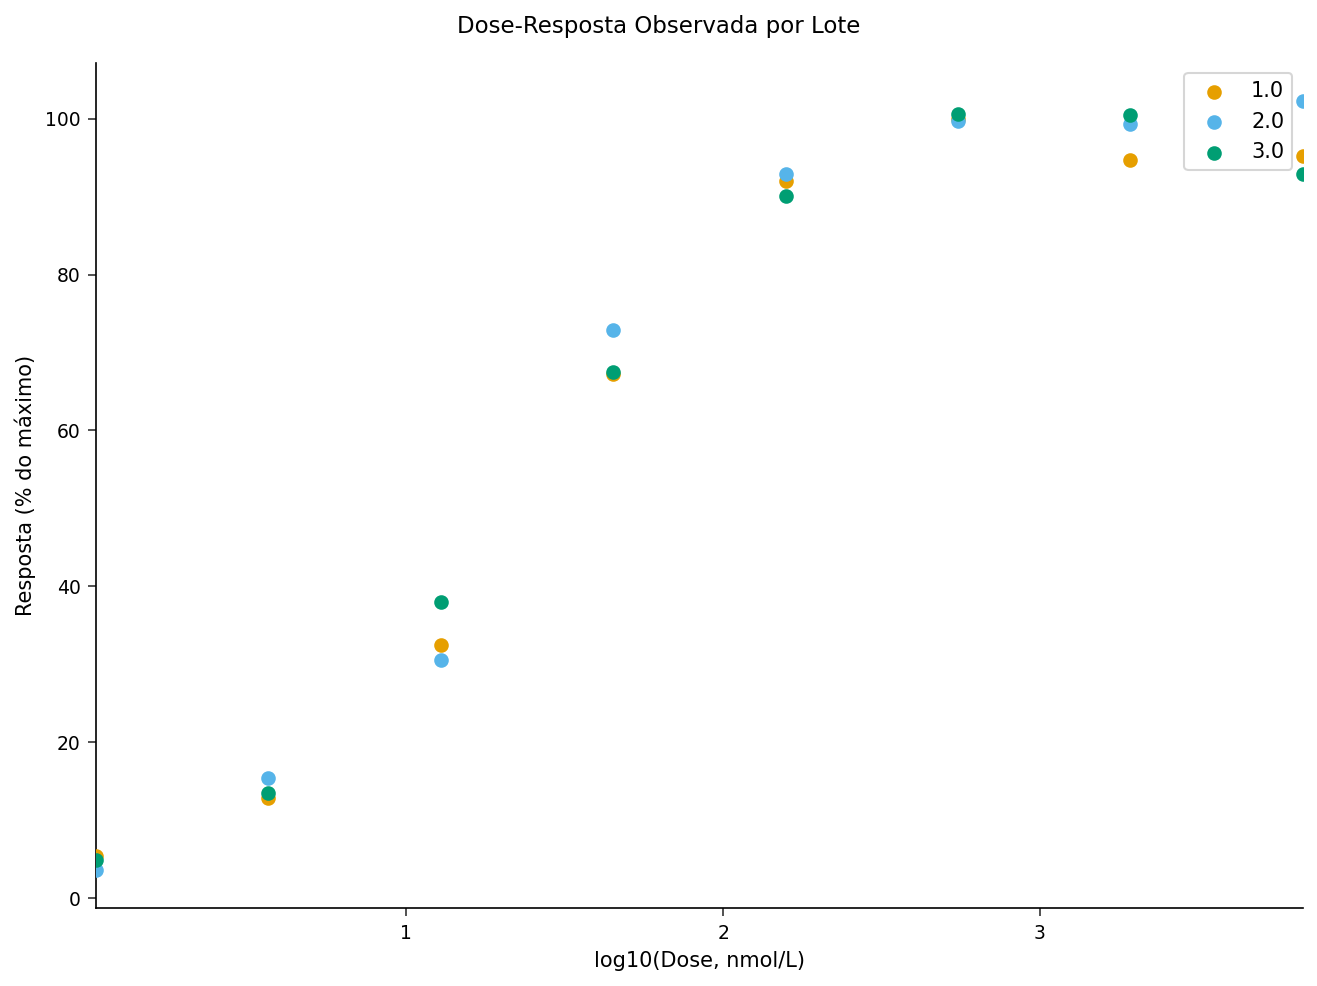

In [2]:
PROCEDIMENTO SGPLOT DADOS=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS RÓTULO='log10(Dose, nmol/L)';
    YAXIS RÓTULO='Resposta (% do máximo)';
    TÍTULO 'Dose-Resposta Observada por Lote';
EXECUTAR;
TÍTULO;


## Etapa 3 — Ajustar o modelo 4PL com PROC NLIN

Declaramos valores iniciais com `PARMS` (informados pelo gráfico de dispersão), definimos a média 4PL em uma atribuição intermediária e a passamos para a instrução `MODEL`. `BOUNDS` fisicamente significativos mantêm as assíntotas ordenadas e a EC50 e a inclinação positivas, o que estabiliza as iterações de Gauss-Newton. A instrução `OUTPUT` salva os valores preditos, os resíduos e os limites de confiança para diagnósticos posteriores, e `PLOTS=` solicita os painéis de ajuste e de diagnóstico.

In [3]:
PROCEDIMENTO nlin DADOS=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Mantém os parâmetros em regiões fisicamente sensatas */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Resposta média logística de quatro parâmetros (embutida: o PROC NLIN
       do Jenner ainda não suporta referenciar uma variável de instrução de
       programação intermediária na instrução MODEL -- ver tests/400986 --
       então embutimos o denominador) */
    MODELO response = D + (A - D) / (1 + (dose / C) ** B);

    RÓTULO response='Resposta (% do máximo)' dose='Dose (nmol/L)';

    SAÍDA out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
EXECUTAR;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/78b800a0-476e-4f00-8958-46915bb29b50/fit4pl.avro


## Etapa 4 — Relatar a EC50 estimada e as características da curva

O mecanismo `OUTEST=` é conveniente, mas para uma leitura rápida de potência resumimos a curva ajustada diretamente. Aqui listamos os valores ajustados em cada dose ao lado das respostas observadas para confirmar que o modelo acompanha os dados em toda a faixa de diluição.

In [4]:
PROCEDIMENTO MEANS DADOS=fit4pl mean std MIN MAX maxdec=3;
    CLASSE dose;
    VARIÁVEL response pred resid;
    RÓTULO response='Resposta (% do máximo)' pred='Previsto (% do máximo)'
          resid='Resíduo (% do máximo)' dose='Dose (nmol/L)';
    TÍTULO 'Resposta Observada vs Ajustada por Dose';
EXECUTAR;
TÍTULO;


                                        Resposta Observada vs Ajustada por Dose                                         

                                                  The MEANS Procedure

                                 Analysis Variable : RESPONSE Resposta (% do máximo)

                                           N
                       Dose (nmol/L)     Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.3


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Etapa 5 — Sobrepor a curva 4PL ajustada aos dados observados

Uma grade densa de predição produz uma sigmoide ajustada suave. Combinamos a curva suave com os valores ajustados médios por dose e a banda de confiança e, em seguida, sobrepomos tudo aos pontos observados para avaliar visualmente a qualidade do ajuste.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


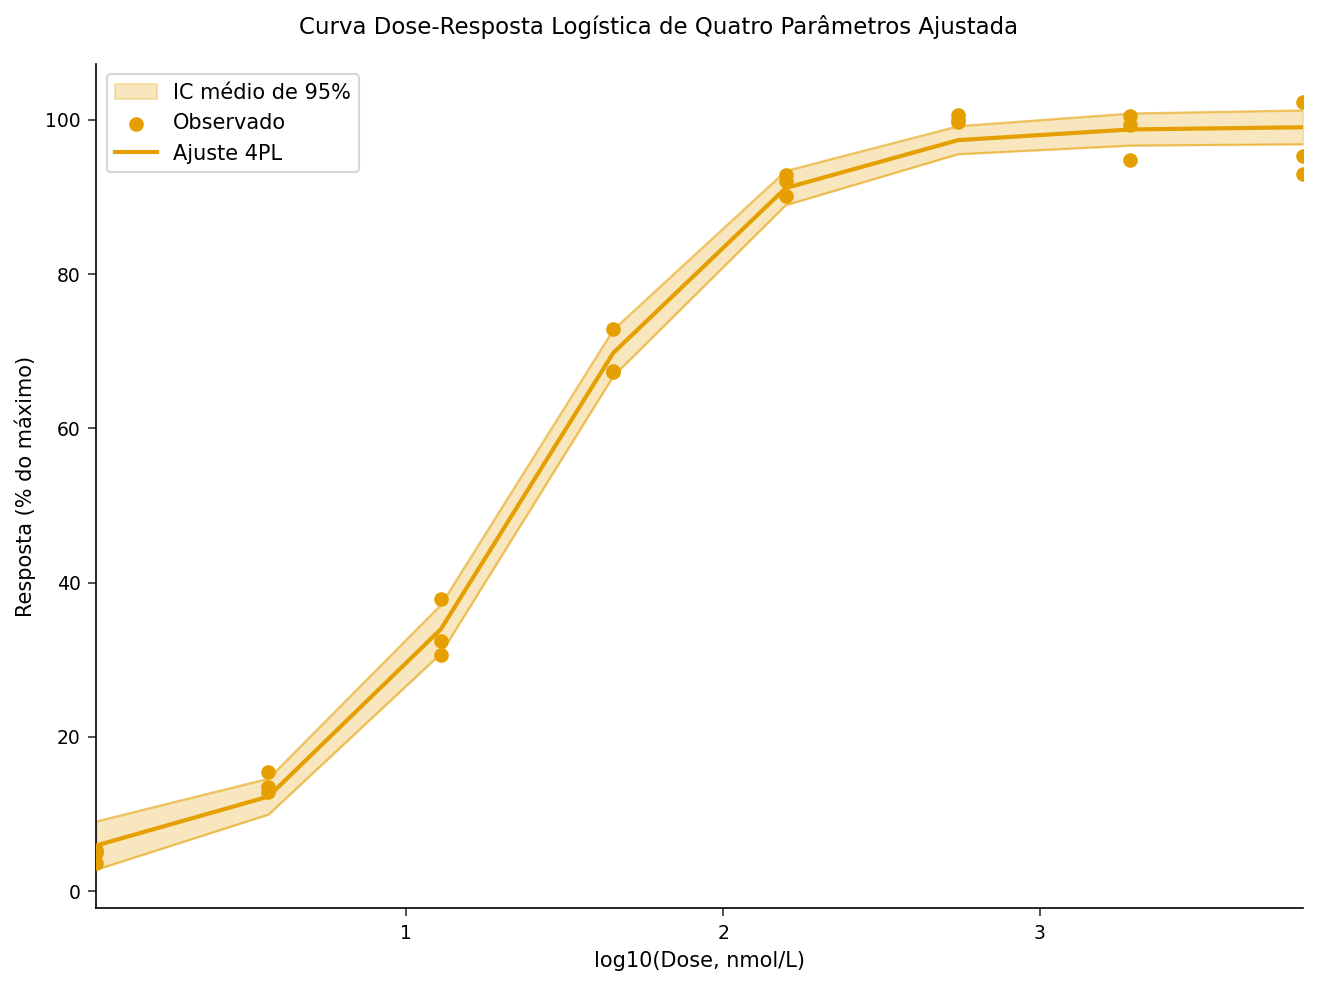

In [5]:
PROCEDIMENTO SORT DADOS=fit4pl;
    POR logdose;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='IC médio de 95%';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Observado';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='Ajuste 4PL';
    XAXIS RÓTULO='log10(Dose, nmol/L)';
    YAXIS RÓTULO='Resposta (% do máximo)';
    TÍTULO 'Curva Dose-Resposta Logística de Quatro Parâmetros Ajustada';
EXECUTAR;
TÍTULO;


## Interpretando os resultados

`PROC NLIN` converge para estimativas próximas dos valores geradores conhecidos: uma assíntota inferior perto de **5**, uma assíntota superior perto de **100**, uma **EC50 (C)** perto de **25 nmol/L** e uma **Hill slope (B)** perto de **1.2**. A recuperação desses parâmetros a partir de dados ruidosos em triplicata confirma que o modelo é identificável e que os limites não se ativaram no ótimo.

A **EC50** é a métrica de potência de destaque: valores mais baixos indicam um composto mais potente e, em um ensaio de potência relativa, a EC50 de um lote de teste é comparada a um padrão de referência. A **Hill slope** caracteriza a cooperatividade e a inclinação do ensaio — uma inclinação perto de 1 é consistente com ligação simples de sítio único. As **assíntotas** definem a faixa dinâmica do ensaio; um piso e um topo estáveis e bem separados são pré-requisitos para um bioensaio validável.

O gráfico de ajuste mostra a sigmoide passando pela nuvem de pontos observados com uma banda de confiança média de 95% estreita ao longo da região responsiva, e os diagnósticos de resíduos não devem apresentar curvatura sistemática — evidência de que a forma 4PL é adequada. Na prática, você estenderia este fluxo de trabalho com intervalos de verossimilhança `PROFILE` para a EC50, uma instrução `BOOTSTRAP` para inferência de parâmetros livre de distribuição, ou uma análise de linhas paralelas comparando lotes de teste e de referência para estimar a potência relativa.